In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import json

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import json

# Path to dataset
BASE_PATH = "/content/drive/MyDrive/extracted_frames/"
ANNOTATIONS_PATH = "/content/drive/MyDrive/annotations_1531762138.1303267.json"

# Verify paths exist
print("Dataset exists:", os.path.exists(BASE_PATH))
print("Annotations exist:", os.path.exists(ANNOTATIONS_PATH))

Dataset exists: True
Annotations exist: True


In [ ]:
#  all video folders
video_folders = sorted(os.listdir(BASE_PATH))
print(f"Total videos: {len(video_folders)}")
print(f"First 5 videos: {video_folders[:5]}")
print(f"Last 5 videos: {video_folders[-5:]}")

#  one video folder
sample_video = BASE_PATH + video_folders[0]
frames = os.listdir(sample_video)
print(f"\nFrames in {video_folders[0]}: {len(frames)}")

Total videos: 1416
First 5 videos: ['000000', '000001', '000002', '000003', '000004']
Last 5 videos: ['001411', '001412', '001413', '001414', '001415']

Frames in 000000: 662


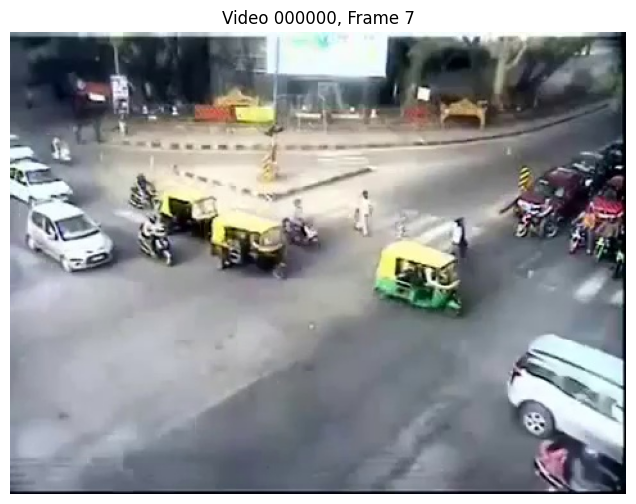

Original image size: (480, 360)


In [ ]:
def load_and_show_frame(video_id, frame_num):
    """Load and display a specific frame"""
    img_path = f"{BASE_PATH}{video_id}/{frame_num}.jpg"
    img = Image.open(img_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Video {video_id}, Frame {frame_num}")
    plt.axis('off')
    plt.show()
    return img

# Test it
img = load_and_show_frame("000000", 7)
print(f"Original image size: {img.size}")

In [ ]:
def preprocess_frame(img):
    """Resize and normalize a frame"""
    # Resize to 224x224
    img = img.resize((224, 224))
    # Convert to array
    img_array = np.array(img)
    # Normalize to [0, 1]
    img_array = img_array / 255.0
    return img_array

# Test it
processed = preprocess_frame(img)
print(f"Processed shape: {processed.shape}")  # Should be (224, 224, 3)
print(f"Pixel range: {processed.min()} to {processed.max()}")  # Should be 0.0 to 1.0

Processed shape: (224, 224, 3)
Pixel range: 0.0 to 1.0


In [ ]:
def load_video_sequence(video_id, num_frames=16):
    """Load and preprocess a sequence of frames from one video"""
    video_path = BASE_PATH + video_id + "/"

    frames = []
    for i in range(num_frames):
        img_path = f"{video_path}{i}.jpg"
        img = Image.open(img_path)
        processed = preprocess_frame(img)
        frames.append(processed)

    # Stack into array
    sequence = np.array(frames)
    return sequence

# Test it
sequence = load_video_sequence("000001", num_frames=16)
print(f"Sequence shape: {sequence.shape}")

Sequence shape: (16, 224, 224, 3)


In [ ]:
# Load duration list
with open("/content/drive/MyDrive/duration_list.txt") as f:
    duration_data = f.read()

print(duration_data[:1000])  # First 1000 characters

-GpvLzopst8.mp4 00:01:01.07
-UQZMlA_xEs.mp4 00:07:48.04
-r48Lr-jBSI.mp4 00:08:01.61
08PPPXtzN4A.mp4 00:00:32.07
0IPAgFHyRVI.mp4 00:00:12.54
0NixrF6Mt00.mp4 00:03:23.08
1XIS9UOwC_Y.mp4 00:03:24.68
1tBtgW63TVI.mp4 00:01:08.89
2NOe6_DPCzw.mp4 00:07:13.19
2aCk4KHP-K0.mp4 00:01:02.04
3BkEfTlLfoA.mp4 00:14:20.93
3ItkjSXfP6k.mp4 00:00:11.33
3KSHg1inZS8.mp4 00:02:35.11
3LsNpm5y-VA.mp4 00:15:46.21
3PlZn2L6lJA.mp4 00:07:18.39
3QsW1X6RE4U.mp4 00:00:22.64
3VTdPoH5eGE.mp4 00:00:30.05
3Xd6PxEvbNk.mp4 00:03:32.14
3h_zF5nLVy4.mp4 00:07:07.73
3p_-1RjvCmw.mp4 00:00:37.01
4gFiGGeTp5w.mp4 00:08:18.63
5F7cUPAOMno.mp4 00:02:53.27
5IrqZnvHUsY.mp4 00:01:12.21
5dwPSzpV9pw.mp4 00:00:36.99
5pGjkv5lZXE.mp4 00:10:45.51
651RQwxB3WA.mp4 00:09:17.05
67eBRe-YfEE.mp4 00:10:19.14
6WsQv9LKQDQ.mp4 00:01:21.78
6mVcTFd5TzI.mp4 00:03:32.46
7YEUfIVVk9Y.mp4 00:05:11.57
7pftzwaA0iM.mp4 00:00:58.17
9DRFJxKHc6g.mp4 00:10:45.33
9fKAb-gGLRM.mp4 00:09:28.15
9jBSHJJQI5M.mp4 00:10:28.12
9kj6f2iSkrI.mp4 00:05:32.53
AJKLxHzIHYY.mp4 00:0

In [ ]:
for f in os.listdir('/content/drive/MyDrive/'):
    if f.endswith('.txt') or f.endswith('.json'):
        print(f)

annotations_1531762138.1303267.json
duration_list.txt
duration_seconds.txt


In [ ]:
with open("/content/drive/MyDrive/duration_seconds.txt") as f:
    data = f.read()
print(data[:500])

-GpvLzopst8.mp4 61.068333
61.068333
-UQZMlA_xEs.mp4 468.044622
529.112955
-r48Lr-jBSI.mp4 481.605078
1010.718033
08PPPXtzN4A.mp4 32.066756
1042.784789
0IPAgFHyRVI.mp4 12.538333
1055.323122
0NixrF6Mt00.mp4 203.081722
1258.404844
1XIS9UOwC_Y.mp4 204.683333
1463.088177
1tBtgW63TVI.mp4 68.893333
1531.981510
2NOe6_DPCzw.mp4 433.191467
1965.172977
2aCk4KHP-K0.mp4 62.043711
2027.216688
3BkEfTlLfoA.mp4 860.926733
2888.143421
3ItkjSXfP6k.mp4 11.330000
2899.473421
3KSHg1inZS8.mp4 155.108333
3054.581754
3L


In [ ]:
with open("/content/drive/MyDrive/duration_list.txt") as f:
    data2 = f.read()
print(data2[:300])

-GpvLzopst8.mp4 00:01:01.07
-UQZMlA_xEs.mp4 00:07:48.04
-r48Lr-jBSI.mp4 00:08:01.61
08PPPXtzN4A.mp4 00:00:32.07
0IPAgFHyRVI.mp4 00:00:12.54
0NixrF6Mt00.mp4 00:03:23.08
1XIS9UOwC_Y.mp4 00:03:24.68
1tBtgW63TVI.mp4 00:01:08.89
2NOe6_DPCzw.mp4 00:07:13.19
2aCk4KHP-K0.mp4 00:01:02.04
3BkEfTlLfoA.mp4 00:1


In [ ]:
# Parse duration_seconds.txt - YouTube ID to duration
yt_durations = {}
with open("/content/drive/MyDrive/duration_seconds.txt") as f:
    lines = f.read().strip().split('\n')

for line in lines:
    parts = line.strip().split(' ')
    if len(parts) == 2 and parts[0].endswith('.mp4'):
        yt_durations[parts[0]] = float(parts[1])

print("Total YouTube videos with duration:", len(yt_durations))
print("Sample:", list(yt_durations.items())[:3])

Total YouTube videos with duration: 230
Sample: [('-GpvLzopst8.mp4', 61.068333), ('-UQZMlA_xEs.mp4', 468.044622), ('-r48Lr-jBSI.mp4', 481.605078)]


In [ ]:
import os

FRAMES_PATH = "/content/drive/MyDrive/extracted_frames/"

folder_durations = {}

folders = sorted(os.listdir(FRAMES_PATH))

for folder in folders:

    folder_path = os.path.join(FRAMES_PATH, folder)

    if os.path.isdir(folder_path):

        frames = os.listdir(folder_path)
        frame_count = len(frames)

        duration = frame_count / 10   # CADP fps ≈ 10

        folder_durations[folder] = duration

print("Total folders:", len(folder_durations))
print(list(folder_durations.items())[:5])

Total folders: 1416
[('000000', 66.2), ('000001', 70.2), ('000002', 36.0), ('000003', 23.3), ('000004', 15.9)]


In [ ]:
mapping = {}

for yt_id, yt_dur in yt_durations.items():
    # Find folder with closest duration
    closest_folder = min(folder_durations.items(), key=lambda x: abs(x[1] - yt_dur))
    mapping[yt_id] = closest_folder[0]

print("Total matches:", len(mapping))
print(list(mapping.items())[:5])

Total matches: 230
[('-GpvLzopst8.mp4', '000667'), ('-UQZMlA_xEs.mp4', '000959'), ('-r48Lr-jBSI.mp4', '000959'), ('08PPPXtzN4A.mp4', '001238'), ('0IPAgFHyRVI.mp4', '000082')]


In [ ]:
import os

FPS = 10  # CADP frame rate
errors = []

for yt_id, folder in mapping.items():
    yt_dur = yt_durations[yt_id]
    folder_dur = folder_durations[folder]

    folder_path = os.path.join(FRAMES_PATH, folder)
    actual_frames = len(os.listdir(folder_path))
    expected_frames = int(yt_dur * FPS)

    duration_diff = abs(yt_dur - folder_dur)
    frame_diff = abs(actual_frames - expected_frames)

    # flag if differences are unusually high
    if duration_diff > 5 or frame_diff > 5:
        errors.append((yt_id, folder, duration_diff, frame_diff))

print("Number of potential mismatches:", len(errors))
print("Examples:", errors[:5])

Number of potential mismatches: 145
Examples: [('-UQZMlA_xEs.mp4', '000959', 10.444621999999981, 104), ('-r48Lr-jBSI.mp4', '000959', 24.00507799999997, 240), ('0NixrF6Mt00.mp4', '000489', 4.518277999999981, 46), ('1XIS9UOwC_Y.mp4', '000489', 2.9166669999999897, 30), ('3LsNpm5y-VA.mp4', '001409', 45.08833299999992, 451)]


In [ ]:
# Get accident timing for all 226 videos
with open(ANNOTATIONS_PATH) as f:
    annotations = json.load(f)

accident_times = []

for yt_id, data in annotations.items():
    if data:  # has annotation
        first_frame = data[0]['keyframes'][0]['frame']

        # get duration of this video
        yt_id_with_ext = yt_id if yt_id.endswith('.mp4') else yt_id + '.mp4'

        if yt_id_with_ext in yt_durations:
            total_duration = yt_durations[yt_id_with_ext]
            accident_ratio = first_frame / (total_duration * 10)  # 10 fps
            accident_times.append({
                'video': yt_id,
                'accident_frame': first_frame,
                'total_duration_sec': total_duration,
                'accident_ratio': accident_ratio
            })
            print(f"{yt_id}: frame={first_frame:.0f}, duration={total_duration:.1f}s, ratio={accident_ratio:.2f}")

print(f"\nTotal videos analyzed: {len(accident_times)}")
print(f"Average accident ratio: {sum(x['accident_ratio'] for x in accident_times)/len(accident_times):.2f}")

-GpvLzopst8.mp4: frame=0, duration=61.1s, ratio=0.00
08PPPXtzN4A.mp4: frame=0, duration=32.1s, ratio=0.00
0IPAgFHyRVI.mp4: frame=0, duration=12.5s, ratio=0.00
0NixrF6Mt00.mp4: frame=81, duration=203.1s, ratio=0.04
1XIS9UOwC_Y.mp4: frame=0, duration=204.7s, ratio=0.00
1tBtgW63TVI.mp4: frame=0, duration=68.9s, ratio=0.00
2NOe6_DPCzw.mp4: frame=78, duration=433.2s, ratio=0.02
2aCk4KHP-K0.mp4: frame=5, duration=62.0s, ratio=0.01
3ItkjSXfP6k.mp4: frame=0, duration=11.3s, ratio=0.00
3KSHg1inZS8.mp4: frame=0, duration=155.1s, ratio=0.00
3LsNpm5y-VA.mp4: frame=1, duration=946.2s, ratio=0.00
3PlZn2L6lJA.mp4: frame=255, duration=438.4s, ratio=0.06
3QsW1X6RE4U.mp4: frame=0, duration=22.6s, ratio=0.00
3VTdPoH5eGE.mp4: frame=7, duration=30.0s, ratio=0.02
3Xd6PxEvbNk.mp4: frame=0, duration=212.1s, ratio=0.00
3p_-1RjvCmw.mp4: frame=0, duration=37.0s, ratio=0.00
4gFiGGeTp5w.mp4: frame=185, duration=498.6s, ratio=0.04
5IrqZnvHUsY.mp4: frame=19, duration=72.2s, ratio=0.03
5dwPSzpV9pw.mp4: frame=0, durat

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_PATH = "/content/drive/MyDrive/extracted_frames/"
SAVE_PATH = "/content/drive/MyDrive/"
IMG_SIZE = 224
N_FRAMES = 16
ACCIDENT_RATIO = 0.30
BATCH_SIZE = 100

def load_frame(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32) / 255.0

def get_sequence(folder_path, files, start_idx, end_idx):
    indices = np.linspace(start_idx, end_idx, N_FRAMES, dtype=int)
    frames = []
    for idx in indices:
        frame = load_frame(os.path.join(folder_path, files[idx]))
        if frame is None:
            return None
        frames.append(frame)
    return np.array(frames)

def process_folder(folder_path):
    files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith(".jpg")],
        key=lambda x: int(os.path.splitext(x)[0])
    )
    total = len(files)
    cutoff = int(total * ACCIDENT_RATIO)

    if cutoff < N_FRAMES or (total - cutoff) < N_FRAMES:
        return None

    acc_seq = get_sequence(folder_path, files, 0, cutoff - 1)
    norm_seq = get_sequence(folder_path, files, cutoff, total - 1)

    if acc_seq is None or norm_seq is None:
        return None

    return acc_seq, norm_seq

folders = sorted([
    f for f in os.listdir(BASE_PATH)
    if os.path.isdir(os.path.join(BASE_PATH, f))
])
print(f"Found {len(folders)} folders")

X, y = [], []
skipped = 0
batch_num = 0

for i, folder in enumerate(tqdm(folders, desc="Building dataset")):
    result = process_folder(os.path.join(BASE_PATH, folder))

    if result is None:
        skipped += 1
        continue

    acc_seq, norm_seq = result
    X.append(acc_seq)
    y.append(1)
    X.append(norm_seq)
    y.append(0)

    if (i + 1) % BATCH_SIZE == 0:
        np.save(f"{SAVE_PATH}X_batch_{batch_num}.npy", np.array(X))
        np.save(f"{SAVE_PATH}y_batch_{batch_num}.npy", np.array(y))
        print(f"Saved batch {batch_num} ✅  (accidents: {sum(y)}, normal: {y.count(0)})")
        X, y = [], []
        batch_num += 1

if X:
    np.save(f"{SAVE_PATH}X_batch_{batch_num}.npy", np.array(X))
    np.save(f"{SAVE_PATH}y_batch_{batch_num}.npy", np.array(y))
    print(f"Saved final batch {batch_num} ✅")

print(f"\nDone! Total batches: {batch_num + 1} | Skipped: {skipped}")

Found 1416 folders


Building dataset:   7%|▋         | 100/1416 [03:47<2:58:59,  8.16s/it]

Saved batch 0 ✅  (accidents: 89, normal: 89)


Building dataset:  14%|█▍        | 200/1416 [12:09<3:38:21, 10.77s/it]

Saved batch 1 ✅  (accidents: 100, normal: 100)


...

Building dataset:  64%|██████▎   | 900/1416 [1:38:53<1:40:40, 11.71s/it]

Saved batch 8 ✅  (accidents: 97, normal: 97)


Building dataset:  71%|███████   | 1000/1416 [1:54:09<1:31:48, 13.24s/it]

Saved batch 9 ✅  (accidents: 96, normal: 96)


Building dataset:  71%|███████   | 1005/1416 [1:55:03<1:12:04, 10.52s/it]

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_PATH = "/content/drive/MyDrive/extracted_frames/"
SAVE_PATH = "/content/drive/MyDrive/"
IMG_SIZE = 224
N_FRAMES = 16
ACCIDENT_RATIO = 0.30
BATCH_SIZE = 100
START_FROM = 900
START_BATCH = 9

def load_frame(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32) / 255.0

def get_sequence(folder_path, files, start_idx, end_idx):
    indices = np.linspace(start_idx, end_idx, N_FRAMES, dtype=int)
    frames = []
    for idx in indices:
        frame = load_frame(os.path.join(folder_path, files[idx]))
        if frame is None:
            return None
        frames.append(frame)
    return np.array(frames)

def process_folder(folder_path):
    files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith(".jpg")],
        key=lambda x: int(os.path.splitext(x)[0])
    )
    total = len(files)
    cutoff = int(total * ACCIDENT_RATIO)

    if cutoff < N_FRAMES or (total - cutoff) < N_FRAMES:
        return None

    acc_seq = get_sequence(folder_path, files, 0, cutoff - 1)
    norm_seq = get_sequence(folder_path, files, cutoff, total - 1)

    if acc_seq is None or norm_seq is None:
        return None

    return acc_seq, norm_seq

folders = sorted([
    f for f in os.listdir(BASE_PATH)
    if os.path.isdir(os.path.join(BASE_PATH, f))
])[START_FROM:]

print(f"Resuming from folder {START_FROM}, {len(folders)} folders remaining")

X, y = [], []
skipped = 0
batch_num = START_BATCH

for i, folder in enumerate(tqdm(folders, desc="Resuming dataset")):
    result = process_folder(os.path.join(BASE_PATH, folder))

    if result is None:
        skipped += 1
        continue

    acc_seq, norm_seq = result
    X.append(acc_seq)
    y.append(1)
    X.append(norm_seq)
    y.append(0)

    if (i + 1) % BATCH_SIZE == 0:
        np.save(f"{SAVE_PATH}X_batch_{batch_num}.npy", np.array(X))
        np.save(f"{SAVE_PATH}y_batch_{batch_num}.npy", np.array(y))
        print(f"Saved batch {batch_num} ✅ (accidents: {sum(y)}, normal: {y.count(0)})")
        X, y = [], []
        batch_num += 1

if X:
    np.save(f"{SAVE_PATH}X_batch_{batch_num}.npy", np.array(X))
    np.save(f"{SAVE_PATH}y_batch_{batch_num}.npy", np.array(y))
    print(f"Saved final batch {batch_num} ✅")

print(f"\nDone! Total batches: {batch_num + 1} | Skipped: {skipped}")

Resuming from folder 900, 516 folders remaining


Resuming dataset:  19%|█▉        | 100/516 [14:18<1:47:40, 15.53s/it]

Saved batch 9 ✅ (accidents: 96, normal: 96)


Resuming dataset:  39%|███▉      | 200/516 [23:59<1:15:00, 14.24s/it]

Saved batch 10 ✅ (accidents: 99, normal: 99)


...

Saved batch 12 ✅ (accidents: 100, normal: 100)


Resuming dataset:  97%|█████████▋| 500/516 [52:04<03:13, 12.10s/it]

Saved batch 13 ✅ (accidents: 100, normal: 100)


Resuming dataset: 100%|██████████| 516/516 [53:53<00:00,  6.27s/it]


Saved final batch 14 ✅

Done! Total batches: 15 | Skipped: 7


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

SAVE_PATH = "/content/drive/MyDrive/"

# Load only labels
y_all = []
for i in range(15):
    y_batch = np.load(f"{SAVE_PATH}y_batch_{i}.npy")
    y_all.extend(y_batch.tolist())

y_all = np.array(y_all)
print(f"Total samples: {len(y_all)}")
print(f"Accidents: {y_all.sum()} | Normal: {(y_all==0).sum()}")

# Split indices
all_idx = np.arange(len(y_all))
idx_temp, idx_test = train_test_split(all_idx, test_size=0.15, random_state=42, stratify=y_all)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.176, random_state=42, stratify=y_all[idx_temp])

print(f"\nTrain: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

# Save indices and labels
np.save(f"{SAVE_PATH}idx_train.npy", idx_train)
np.save(f"{SAVE_PATH}idx_val.npy", idx_val)
np.save(f"{SAVE_PATH}idx_test.npy", idx_test)
np.save(f"{SAVE_PATH}y_all.npy", y_all)

print("Saved ✅")

Total samples: 2754
Accidents: 1377 | Normal: 1377

Train: 1928 | Val: 412 | Test: 414
Saved ✅


In [ ]:
import numpy as np

SAVE_PATH = "/content/drive/MyDrive/"

idx_train = np.load(f"{SAVE_PATH}idx_train.npy")
idx_val = np.load(f"{SAVE_PATH}idx_val.npy")
idx_test = np.load(f"{SAVE_PATH}idx_test.npy")
y_all = np.load(f"{SAVE_PATH}y_all.npy")

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
print(f"Total labels: {len(y_all)}")

Train: 1928 | Val: 412 | Test: 414
Total labels: 2754


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

SAVE_PATH = "/content/drive/MyDrive/"

# Load indices and labels
idx_train = np.load(f"{SAVE_PATH}idx_train.npy")
idx_val = np.load(f"{SAVE_PATH}idx_val.npy")
idx_test = np.load(f"{SAVE_PATH}idx_test.npy")
y_all = np.load(f"{SAVE_PATH}y_all.npy")

# Load ResNet50
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
resnet.trainable = False
print("ResNet50 loaded ✅")

def extract_features_efficient(indices):
    batch_size = 200
    batch_groups = {}
    for idx in indices:
        batch_num = idx // batch_size
        sample_in_batch = idx % batch_size
        if batch_num not in batch_groups:
            batch_groups[batch_num] = []
        batch_groups[batch_num].append((idx, sample_in_batch))

    features_dict = {}

    for batch_num, samples in tqdm(batch_groups.items(), desc="Processing batches"):
        X_batch = np.load(f"{SAVE_PATH}X_batch_{batch_num}.npy")
        actual_size = len(X_batch)

        for global_idx, sample_in_batch in samples:
            if sample_in_batch >= actual_size:
                continue
            frames = X_batch[sample_in_batch]
            frames_preprocessed = preprocess_input(frames * 255.0)
            frame_features = resnet.predict(frames_preprocessed, verbose=0)
            video_feature = frame_features.mean(axis=0)
            features_dict[global_idx] = video_feature

        del X_batch

    return np.array([features_dict[idx] for idx in indices if idx in features_dict])

print("\nExtracting train features...")
X_train_feat = extract_features_efficient(idx_train)
print("Extracting val features...")
X_val_feat = extract_features_efficient(idx_val)
print("Extracting test features...")
X_test_feat = extract_features_efficient(idx_test)

y_train = y_all[idx_train]
y_val = y_all[idx_val]
y_test = y_all[idx_test]

print(f"\nFeature shapes: Train {X_train_feat.shape} | Val {X_val_feat.shape} | Test {X_test_feat.shape}")

print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_feat, y_train)

val_preds = lr.predict(X_val_feat)
test_preds = lr.predict(X_test_feat)

print("\n── Validation Results ──")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(classification_report(y_val, val_preds, target_names=['Normal', 'Accident']))

print("\n── Test Results ──")
print(f"Accuracy: {accuracy_score(y_test, test_preds):.4f}")
print(classification_report(y_test, test_preds, target_names=['Normal', 'Accident']))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_preds))

np.save(f"{SAVE_PATH}X_train_feat.npy", X_train_feat)
np.save(f"{SAVE_PATH}X_val_feat.npy", X_val_feat)
np.save(f"{SAVE_PATH}X_test_feat.npy", X_test_feat)
print("\nFeatures saved to Drive ✅")

ResNet50 loaded ✅

Extracting train features...


Processing batches: 100%|██████████| 14/14 [13:00<00:00, 55.77s/it]


Extracting val features...


Processing batches: 100%|██████████| 14/14 [03:09<00:00, 13.52s/it]


Extracting test features...


Processing batches: 100%|██████████| 14/14 [03:08<00:00, 13.49s/it]


Feature shapes: Train (1879, 2048) | Val (395, 2048) | Test (402, 2048)

Training Logistic Regression...


ValueError: Found input variables with inconsistent numbers of samples: [1879, 1928]

In [ ]:
# Fix labels to match extracted features
def get_valid_indices(indices):
    batch_size = 200
    valid = []
    for idx in indices:
        batch_num = idx // batch_size
        sample_in_batch = idx % batch_size
        X_batch = np.load(f"{SAVE_PATH}X_batch_{batch_num}.npy")
        if sample_in_batch < len(X_batch):
            valid.append(idx)
    return np.array(valid)

# Just reload the saved features and fix labels
idx_train_valid = np.array([idx for idx in idx_train if idx in range(len(y_all))])
y_train = y_all[idx_train[:len(X_train_feat)]]
y_val = y_all[idx_val[:len(X_val_feat)]]
y_test = y_all[idx_test[:len(X_test_feat)]]

print(f"X_train: {X_train_feat.shape} | y_train: {y_train.shape}")
print(f"X_val: {X_val_feat.shape} | y_val: {y_val.shape}")
print(f"X_test: {X_test_feat.shape} | y_test: {y_test.shape}")

# Train
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_feat, y_train)

val_preds = lr.predict(X_val_feat)
test_preds = lr.predict(X_test_feat)

print("\n── Validation Results ──")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(classification_report(y_val, val_preds, target_names=['Normal', 'Accident']))

print("\n── Test Results ──")
print(f"Accuracy: {accuracy_score(y_test, test_preds):.4f}")
print(classification_report(y_test, test_preds, target_names=['Normal', 'Accident']))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_preds))

X_train: (1879, 2048) | y_train: (1879,)
X_val: (395, 2048) | y_val: (395,)
X_test: (402, 2048) | y_test: (402,)

── Validation Results ──
Accuracy: 0.5063
              precision    recall  f1-score   support

      Normal       0.51      0.47      0.49       198
    Accident       0.50      0.54      0.52       197

    accuracy                           0.51       395
   macro avg       0.51      0.51      0.51       395
weighted avg       0.51      0.51      0.51       395


── Test Results ──
Accuracy: 0.4876
              precision    recall  f1-score   support

      Normal       0.48      0.46      0.47       200
    Accident       0.49      0.51      0.50       202

    accuracy                           0.49       402
   macro avg       0.49      0.49      0.49       402
weighted avg       0.49      0.49      0.49       402


Confusion Matrix (Test):
[[ 92 108]
 [ 98 104]]
